inherete from Mid-IR metalens_xz_smaller_spp_scale_ZBF_Gaussian.ipynb

Now Shi Lei

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web

In [3]:
lda0 = 0.532
freq0 = td.C_0 / lda0

P = 0.380 # period of the unit cell
h = 0.120 # height of the slab

inf_eff = 1e5 # effective infinity

In [6]:
n_si3n4 = 2.02
si3n4 = td.Medium(permittivity=n_si3n4**2)

In [7]:
def make_unit_cell(D):
    pillar_geo = td.Cylinder(center=(0, 0, h/2), radius=D/2, length=h)
    pillar = td.Structure(geometry=pillar_geo, medium=td.Medium(permittivity=1))

    return pillar

# define geometry
substrate_geo = td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, 0), rmax=(inf_eff, inf_eff, h))
substrate = td.Structure(geometry=substrate_geo, medium=si3n4)

# # add a plane wave source
# plane_wave = td.PlaneWave(
#     source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10),
#     size=(td.inf, td.inf, 0),
#     center=(0, 0, -0.1 * lda0),
#     direction="+",
# )

# # define a diffraction monitor to calculate the transmission coeff.
# monitor_t = td.DiffractionMonitor(
#     center=[0, 0, h + 0.5 * lda0], size=[td.inf, td.inf, 0], freqs=[freq0], name="t"
# )

# run_time = 5e-12 / 20

# boundary_spec = td.BoundarySpec(
#     x=td.Boundary.periodic(),
#     y=td.Boundary.periodic(),
#     z=td.Boundary(minus=td.PML(), plus=td.PML()),
# )

Lz = h + 1.2 * lda0 # simulation domain size in z direction
min_steps_per_wvl = 12 # minimum steps per wavelength for the grid

# def make_unit_cell_sim(D):
#     sim = td.Simulation(
#         center=(0, 0, h/2),
#         size=(P, P, Lz),
#         grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl, wavelength=lda0),
#         structures=[make_unit_cell(D), substrate],
#         sources=[plane_wave],
#         monitors=[monitor_t],
#         run_time=run_time,
#         boundary_spec=boundary_spec,
#     )

#     return sim

# Constructing the Full Metalens

In [41]:
R = 20 * lda0 # radius of the designed metalens

# define a grid of cells
r = np.arange(-R, R, P)
print(f"The number of unit cells is {len(r) ** 2 * 4}.")
X, Y = np.meshgrid(r, r)

# # plot the desired phase profile
# plt.pcolormesh(X, Y, phi_map, cmap="binary")
# plt.colorbar()
# plt.show()

The number of unit cells is 12544.


In [42]:
# create pillar geometries at each cell to follow the desired phase profile
pillars_geo = []
D_vals = []
# theta = np.unwrap(np.angle(t))
D = 0.28
for i, x in enumerate(r):
    for j, y in enumerate(r):
        # if x**2 + y**2 <= R**2 and x >= 0 and y >= 0 :
        # if x**2 + y**2 <= R**2:
        if x < R and y < R:
            # D = np.interp(phi_map[i, j], theta, D_list)
            D_vals.append(D)
            pillar_geo = td.Cylinder(center=(x, y, h/2), radius=D / 2, length=h)
            pillars_geo.append(pillar_geo)

# create pillar structure
pillars = td.Structure(geometry=td.GeometryGroup(geometries=pillars_geo), medium=td.Medium(permittivity=1))

In [43]:
# simulation domain size
Lx = 2 * R + lda0
Ly = 2 * R + lda0
Lz = h + 1.3 * lda0

# grids of the projected field position
# xs_far = np.linspace(-3 * lda0, 3 * lda0, 101)
# ys_far = np.linspace(-3 * lda0, 3 * lda0, 101)
xs_far = np.linspace(-R, R, 101)
ys_far = np.linspace(-R, R, 101)

xs_far2 = np.linspace(-R, R, 101)
z_proj = 20
ys_far2 = np.linspace(h + lda0, z_proj, 101)

# add a circularly-pol. Gassian beam source
gaussian_x = td.GaussianPulse(freq0=freq0, fwidth=freq0/10, phase=0)

source_x = td.GaussianBeam(
    source_time=gaussian_x,
    size=(td.inf, td.inf, 0),
    center=(0, 0, -0.1 * lda0),
    direction="+",
    pol_angle=0,
    waist_radius=2, # gemini suggest
    waist_distance=-0.113, # gemini suggest
)

gaussian_y = td.GaussianPulse(freq0=freq0, fwidth=freq0/10, phase=-np.pi/2)
source_y = source_x.updated_copy(source_time=gaussian_y, pol_angle=np.pi/2)

# define a field projection monitor
monitor_proj = td.FieldProjectionCartesianMonitor(
    center=[0, 0, h + 0.6 * lda0],
    size=[td.inf, td.inf, 0],
    freqs=[freq0],
    name="focal_plane_proj",
    proj_axis=2,
    proj_distance=z_proj, # here should change
    x=xs_far,
    y=ys_far,
    custom_origin=(0, 0, 0),
    far_field_approx=False,
)

monitor_proj2 = td.FieldProjectionCartesianMonitor(
    center=[0, 0, h + 0.6 * lda0],
    size=[td.inf, td.inf, 0],
    freqs=[freq0],
    name="focal_plane_proj2",
    proj_axis=0,
    proj_distance=0,
    x=xs_far2,
    y=ys_far2,
    far_field_approx=False,
)

# define the simulation
run_time2 = 5e-12 / 18
sim = td.Simulation(
    center=(0, 0, Lz / 2 - lda0 / 2),
    size=(Lx, Ly, Lz),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl, wavelength=lda0),
    structures=[substrate, pillars],
    sources=[source_x, source_y],
    monitors=[monitor_proj, monitor_proj2],
    run_time=run_time2,
    boundary_spec=td.BoundarySpec(x=td.Boundary.pml(), y=td.Boundary.pml(), z=td.Boundary.pml()),
    # symmetry=(-1, 1, 0),
)

19:27:54 China Standard Time WARNING: Structure at structures[0] was detected as
                             being less than half of a central wavelength from a
                             PML on side z-min. To avoid inaccurate results or  
                             divergence, please increase gap between any        
                             structures and PML or fully extend structure       
                             through the pml.                                   

                             WARNING: Suppressed 7 WARNING messages.            

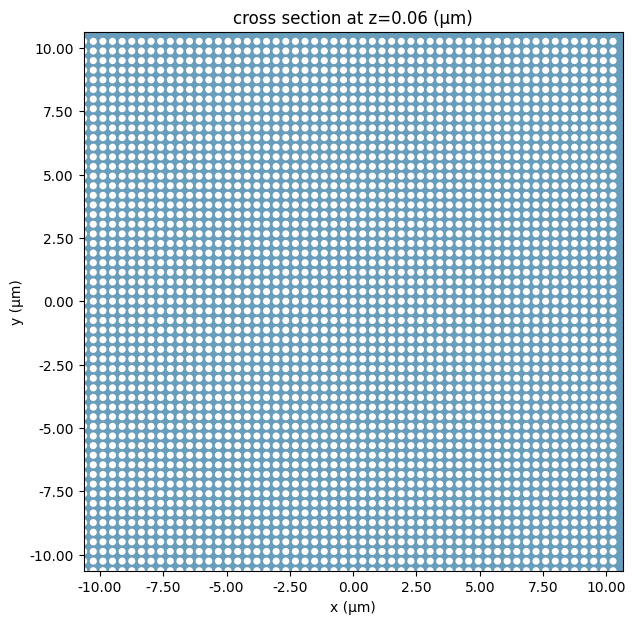

In [44]:
fig, ax= plt.subplots(figsize=(7, 7))
sim.plot(z=h/2, ax=ax)
ax.set_xlim(-R, R)
ax.set_ylim(-R, R)
plt.show()

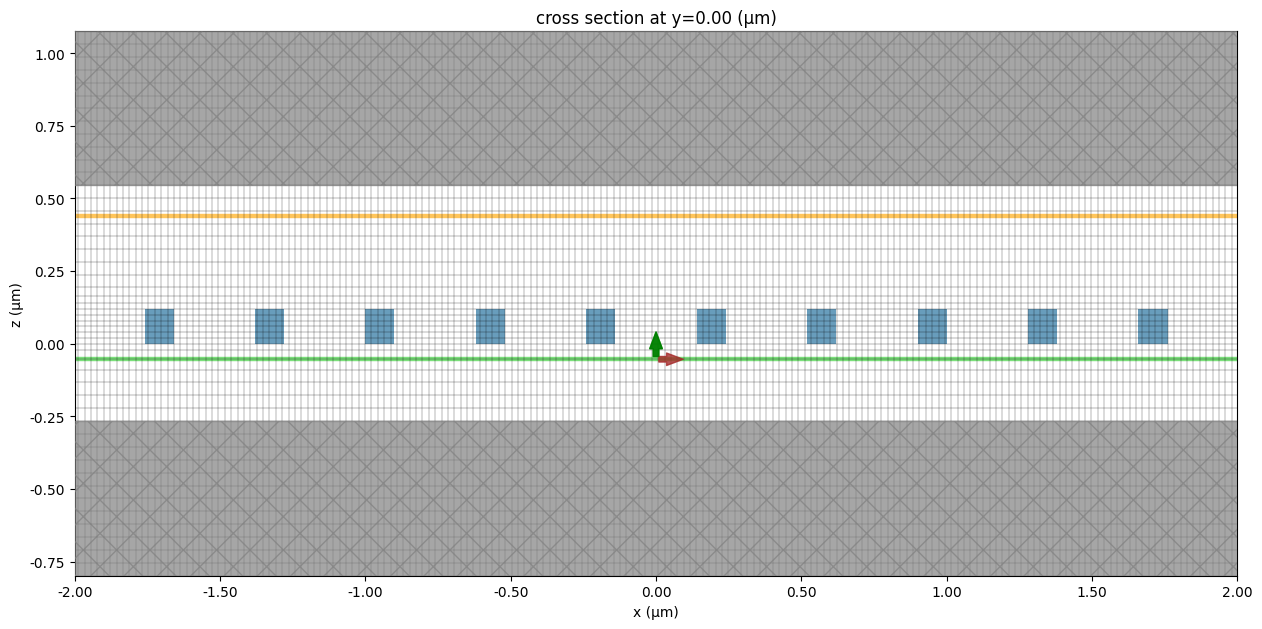

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(15,15))
sim.plot(y=0, ax=ax)
sim.plot_grid(y=0, ax=ax)
# ax.set_aspect(12)
ax.set_xlim(-2, 2)
plt.show()

In [46]:
job = web.Job(simulation=sim, task_name="20260110_Shi_v1")
estimated_cost = web.estimate_cost(job.task_id)

19:28:12 China Standard Time Created task '20260110_Shi_v1' with task_id        
                             'fdve-3fa67045-dc39-41a7-8226-bca58a3e53e2' and    
                             task_type 'FDTD'.

                             View task using web UI at                          
                             ]8;id=583739;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3fa67045-dc39-41a7-8226-bca58a3e53e2\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=643909;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3fa67045-dc39-41a7-8226-bca58a3e53e2\taskId]8;;\]8;id=583739;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3fa67045-dc39-41a7-8226-bca58a3e53e2\=]8;;\]8;id=620042;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3fa67045-dc39-41a7-8226-bca58a3e53e2\f]8;;\
                             ]8;id=620042;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3fa67045-dc39-41a7-8226-bca58a3e53e2\dve]8;;\]8;id=583739;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3fa67045-dc39-41a7-8226-bca58a3e53e2\-3fa67045-dc39-41a7-8226-bca58a3e53e2']8;;\.

                             Task folder: ]8;id=481609;https://tidy3d.simulation.cloud/folders/folder-401c0a0c-8e13-4a51-9b19-e6b8ae1b963e\'default']8;;\.

Output()

19:28:15 China Standard Time Maximum FlexCredit cost: 0.120. Minimum cost       
                             depends on task execution details. Use             
                             'web.real_cost(task_id)' to get the billed         
                             FlexCredit cost after a simulation run.

19:28:17 China Standard Time Maximum FlexCredit cost: 0.120. Minimum cost       
                             depends on task execution details. Use             
                             'web.real_cost(task_id)' to get the billed         
                             FlexCredit cost after a simulation run.

In [47]:
sim_data = job.run(path="20260110_data_Shi/Shi_v1.hdf5")

19:28:37 China Standard Time status = queued

                             To cancel the simulation, use 'web.abort(task_id)' 
                             or 'web.delete(task_id)' or abort/delete the task  
                             in the web UI. Terminating the Python script will  
                             not stop the job running on the cloud.

Output()

19:28:42 China Standard Time status = preprocess

19:28:51 China Standard Time You are running this simulation for FREE. Your     
                             current plan allows up to 20 free non-concurrent   
                             simulations per day (under 100.0M grid points and  
                             50.0K time steps)

...

19:29:17 China Standard Time loading simulation from                            
                             20260110_data_Shi/Shi_v1.hdf5

                             WARNING: Structure at structures[0] was detected as
                             being less than half of a central wavelength from a
                             PML on side z-min. To avoid inaccurate results or  
                             divergence, please increase gap between any        
                             structures and PML or fully extend structure       
                             through the pml.                                   

                             WARNING: Suppressed 7 WARNING messages.            

19:29:18 China Standard Time WARNING: Simulation final field decay value of     
                             0.00176 is greater than the simulation shutoff     
                             threshold of 1e-05. Consider running the simulation
                             again with a larger 'run_time' duration for more   
                             accurate results.                                  

                             WARNING: Warning messages were found in the solver 
                             log. For more information, check                   
                             'SimulationData.log' or use                        
                             'web.download_log(task_id)'.                       

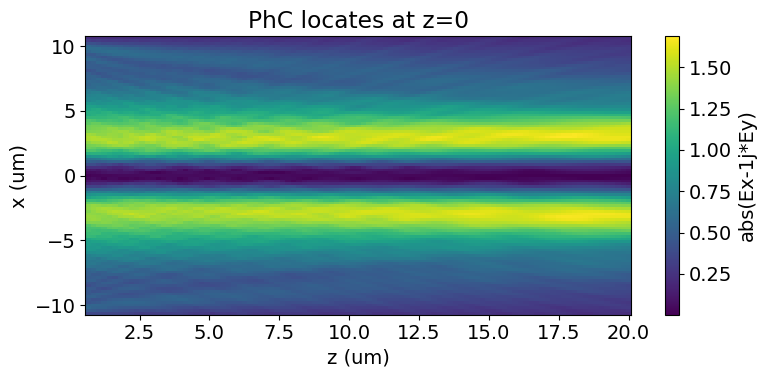

In [84]:
proj_fields = sim_data["focal_plane_proj2"].fields_cartesian.sel(f=freq0, x=0)
plt.rcParams.update({'font.size': 14})
fig, (ax1) = plt.subplots(1, 1, figsize=(8, 4))
im1 = plt.pcolormesh(ys_far2, xs_far2, np.abs(proj_fields.Ex - 1j * proj_fields.Ey), shading="auto")
# 添加colorbar并设置标签
cbar = fig.colorbar(im1, ax=ax1)
cbar.set_label('abs(Ex-1j*Ey)', fontsize=14)  # 单独设置colorbar标签字号
ax1.set_xlabel("z (um)")
ax1.set_ylabel("x (um)")
ax1.set_title("PhC locates at z=0")
plt.tight_layout() 
plt.show()

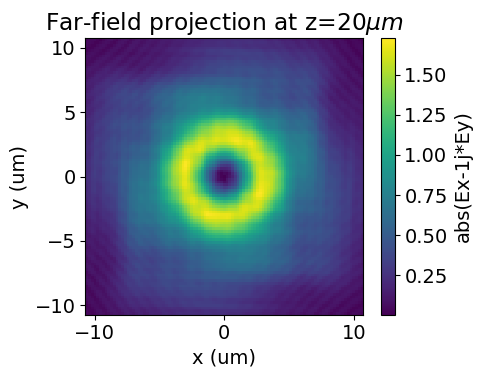

In [87]:
proj_fields = sim_data["focal_plane_proj"].fields_cartesian.sel(f=freq0, z=z_proj)

fig, (ax1) = plt.subplots(1, 1, figsize=(5, 4))
im1 = plt.pcolormesh(ys_far, xs_far, np.abs(proj_fields.Ex - 1j * proj_fields.Ey), shading="auto")

# 添加colorbar并设置标签
cbar = fig.colorbar(im1, ax=ax1)
cbar.set_label('abs(Ex-1j*Ey)', fontsize=14) 
ax1.set_xlabel("x (um)")
ax1.set_ylabel("y (um)")
ax1.set_title("Far-field projection at z=20$\mu m$")
plt.tight_layout() 
plt.show()

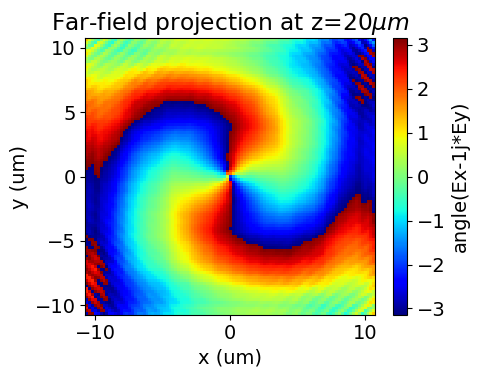

In [90]:
proj_fields = sim_data["focal_plane_proj"].fields_cartesian.sel(f=freq0, z=z_proj)

fig, (ax1) = plt.subplots(1, 1, figsize=(5, 4))
im1 = plt.pcolormesh(ys_far, xs_far, np.angle(proj_fields.Ex - 1j * proj_fields.Ey), cmap="jet", shading="auto")

# 添加colorbar并设置标签
cbar = fig.colorbar(im1, ax=ax1)
cbar.set_label('angle(Ex-1j*Ey)', fontsize=14) 
ax1.set_xlabel("x (um)")
ax1.set_ylabel("y (um)")
ax1.set_title("Far-field projection at z=20$\mu m$")
plt.tight_layout() 
plt.show()